In [ ]:
# Colab setup: run this first on a fresh machine such as Google Colab.
# (Skip if matilda-sc is already installed locally.)
# captum==0.7.0 matches the R package's bundled stack so the feature-selection / marker
# scores agree between the two interfaces (Colab ships a newer captum by default).
%pip install -q "git+https://github.com/PYangLab/Matilda.git" "captum==0.7.0" anndata scanpy

# Matilda in Python

The complete Matilda workflow in **Python** on real **TEA-seq** (RNA + ADT + ATAC): read your
data -> train -> classification -> dimension reduction -> feature selection -> simulation, plus the
modality combinations Matilda supports. A parallel R tutorial with the same structure is available.

Uses the Matilda **object API** (`matilda.train` plus one verb per task:
`matilda.classify` / `reduce` / `markers` / `simulate`), which takes in-memory `AnnData` and
returns result objects (a `TrainResult` from `train`, a `TaskResult` from each task verb), no file paths or output parsing. `classify` reconciles features
automatically: it reuses the model when the query shares the reference panel, and retrains on the
reference∩query intersection when it doesn't.

## Setup

Install the package and download the demo dataset.

```bash
pip install matilda-sc            # once published; during testing:
pip install "git+https://github.com/PYangLab/Matilda.git"
```


In [1]:
import os, urllib.request, tarfile
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import anndata as ad
import matilda                      # import name is `matilda`; PyPI distribution is `matilda-sc`
from matilda import io

# download + cache the demo dataset (first run only)
DATA = os.path.expanduser('~/.cache/matilda/matilda_teaseq_demo')
if not os.path.isdir(DATA):
    url = 'https://github.com/PYangLab/Matilda/releases/download/demo-data/matilda_teaseq_demo.tar.gz'
    os.makedirs(os.path.dirname(DATA), exist_ok=True)
    print('Downloading the Matilda TEA-seq demo (~75 MB) ...')
    tgz, _ = urllib.request.urlretrieve(url)
    tarfile.open(tgz).extractall(os.path.dirname(DATA))
FMT = os.path.join(DATA, 'formats')


## 1. Read your data

Load each modality into an **AnnData** (cells x features) with the reader that matches your format.
`matilda.io` reads the native Matilda `.h5` and 10x; standard `.h5ad` is read with `anndata`. The demo
ships the same training data in three formats, so here we read RNA from `.h5`, ADT from `.h5ad`, and
ATAC from 10x just to show each reader. For your own data you'd normally use one format throughout.

In [2]:
rna  = io.read_matilda_h5(f'{DATA}/train_rna.h5')          # native Matilda .h5  -> AnnData
adt  = ad.read_h5ad(f'{FMT}/train_adt.h5ad')               # standard .h5ad
atac = io.from_10x(f'{FMT}/10x/train_atac', gex_only=False)                # 10x (gex_only=False keeps ADT/ATAC features)
labels = pd.read_csv(f'{DATA}/train_cty.csv', index_col=0).iloc[:, 0].values
print('loaded as AnnData (cells x features):', rna.shape, '|', adt.shape, '|', atac.shape)


loaded as AnnData (cells x features): (1262, 9855) | (1262, 46) | (1262, 14732)


## 2. Train the Matilda model

`matilda.train` takes the in-memory modalities (RNA required; ADT/ATAC optional) and the labels,
picks the matching model from the modalities you pass, and returns a `TrainResult` — the fitted-model handle you pass to every task below via `model=`.


In [3]:
fit = matilda.train(rna, adt, atac, labels=labels, seed=1)
fit


The dataset is TEAseq


  0%|          | 0/30 [00:00<?, ?it/s]

  3%|▎         | 1/30 [00:00<00:08,  3.45it/s]

  7%|▋         | 2/30 [00:00<00:05,  5.33it/s]

 10%|█         | 3/30 [00:00<00:04,  6.48it/s]

...

 67%|██████▋   | 10/15 [00:00<00:00, 13.09it/s]

 80%|████████  | 12/15 [00:00<00:00, 13.12it/s]

 93%|█████████▎| 14/15 [00:01<00:00, 13.17it/s]

100%|██████████| 15/15 [00:01<00:00, 10.46it/s]

TrainResult(mode='TEAseq', n_classes=11, model_path='/tmp/matilda_model_uhg6al13/trained_model/TEAseq/model_best.pth.tar')

## 3. Classification (held-out query cells)

`matilda.classify` labels a query against the trained model, returning a `TaskResult` (every task verb returns one; only the fields that task computes are filled in). The query here is a separate labeled **test set** that ships with the demo (`test_*.h5`, 5048 cells) — not a split of the 1262 training cells; section 7 reuses these same 5048 cells with different modality combinations.

You always pass `reference=` / `labels=` so the *same* call works whether or not the panels match: here the query shares the model's feature panel, so `classify` **reuses** the model (`result.retrained` is `False`) and those two arguments are ignored; if the query were missing features, the identical call would instead **retrain** on the reference∩query intersection. `result.predictions` is a DataFrame (columns `cell_id`, `real`, `predicted`, `probability`) and `result.celltype_accuracy` the per-cell-type accuracy.

In [4]:
te_rna, te_adt, te_atac = (io.read_matilda_h5(f'{DATA}/test_{m}.h5') for m in ['rna', 'adt', 'atac'])
te_lab = pd.read_csv(f'{DATA}/test_cty.csv', index_col=0).iloc[:, 0].values
result = matilda.classify({'rna': te_rna, 'adt': te_adt, 'atac': te_atac}, model=fit,
                          reference={'rna': rna, 'adt': adt, 'atac': atac},
                          labels=labels, query_labels=te_lab)
pred = result.predictions
print('retrained:', result.retrained,
      '| overall query accuracy = %.4f (n=%d)' % ((pred.predicted == pred.real).mean(), len(pred)))


The dataset is TEAseq


retrained: False | overall query accuracy = 0.8092 (n=5048)


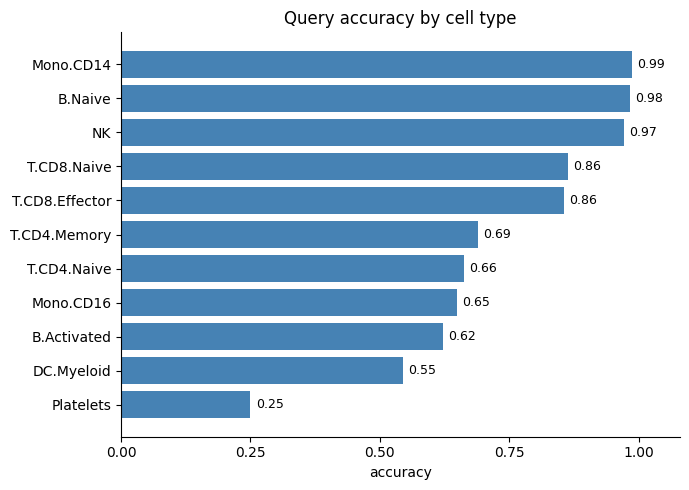

In [5]:
# Per-cell-type accuracy, sorted ascending, drawn as horizontal bars.
acc = result.celltype_accuracy.sort_values('accuracy')

fig, ax = plt.subplots(figsize=(7, 5))
ax.barh(acc['celltype'], acc['accuracy'], color='steelblue')

# annotate each bar with its value
for i, value in enumerate(acc['accuracy']):
    ax.text(value + 0.01, i, f'{value:.2f}', va='center', fontsize=9)

ax.set_xlim(0, 1.08)
ax.set_xticks([0, 0.25, 0.5, 0.75, 1.0])
ax.set_xlabel('accuracy')
ax.set_ylabel('')
ax.spines[['top', 'right']].set_visible(False)
ax.set_title('Query accuracy by cell type')
plt.tight_layout()
plt.show()

## 4. Dimension reduction

`matilda.reduce` returns a `TaskResult` whose `result.latent` is the integrated latent space (cells x z_dim); `result.latent_labels` holds the matching cell labels.


In [6]:
result = matilda.reduce({'rna': rna, 'adt': adt, 'atac': atac}, model=fit, labels=labels)
L   = result.latent
lab = result.latent_labels.iloc[:, 0].values


The dataset is TEAseq
finish dimension reduction


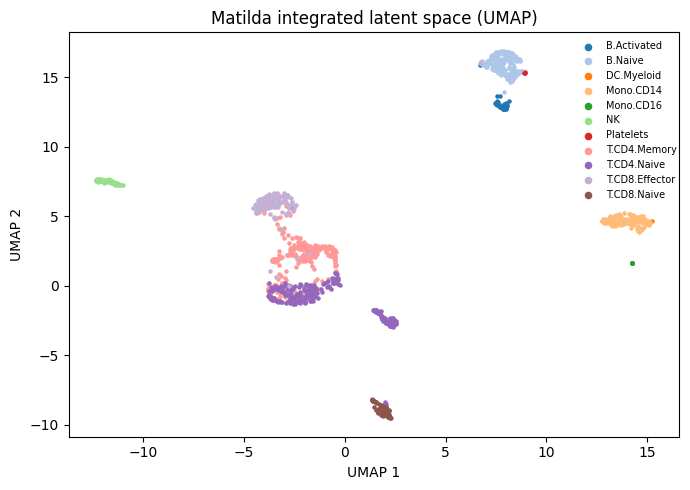

In [7]:
import umap

# UMAP the 100-dim latent space down to 2-D just for plotting.
umap_xy = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42).fit_transform(L.values)

cell_types = sorted(pd.unique(lab))                 # colour whatever cell types the data has
PALETTE = ['#1f77b4', '#aec7e8', '#ff7f0e', '#ffbb78', '#2ca02c', '#98df8a', '#d62728', '#ff9896',
           '#9467bd', '#c5b0d5', '#8c564b', '#c49c94', '#e377c2', '#f7b6d2', '#7f7f7f', '#bcbd22', '#17becf', '#9edae5']
color_of = {ct: PALETTE[i % len(PALETTE)] for i, ct in enumerate(cell_types)}   # wrap palette if >18 types

fig, ax = plt.subplots(figsize=(7, 5))
for ct in cell_types:
    in_type = lab == ct                             # boolean mask: the cells of this type
    ax.scatter(umap_xy[in_type, 0], umap_xy[in_type, 1], s=5, label=ct, color=color_of[ct])

ax.legend(markerscale=2, bbox_to_anchor=(1.01, 1), fontsize=7, frameon=False)
ax.set_title('Matilda integrated latent space (UMAP)')
ax.set_xlabel('UMAP 1')
ax.set_ylabel('UMAP 2')
plt.tight_layout()
plt.show()

## 5. Feature selection

`matilda.markers` returns a `TaskResult` whose `result.markers` is a DataFrame of per-cell-type feature importances (columns `celltype` / `feature` / `importance`).


In [8]:
result = matilda.markers({'rna': rna, 'adt': adt, 'atac': atac}, model=fit, labels=labels, method='IntegratedGradient')
mk  = result.markers
mk.head()


The dataset is TEAseq


finish feature selection


,celltype,feature,importance
0,B.Activated,LINC01409,0.048313
1,B.Activated,LINC01128,0.027807
2,B.Activated,NOC2L,0.018507
3,B.Activated,HES4,0.051471
4,B.Activated,ISG15,0.019143


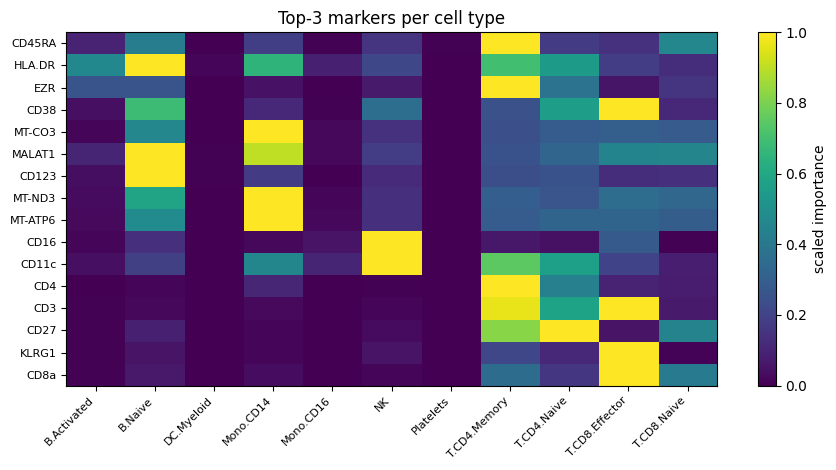

In [9]:
# Build a feature x cell-type matrix from each cell type's top-3 markers.
cell_types = sorted(mk.celltype.unique())
top3 = pd.concat([mk[mk.celltype == ct].sort_values('importance', ascending=False).head(3)
                  for ct in cell_types])
feature_order = list(dict.fromkeys(top3.feature))          # unique features, keeping first-seen order

heat = (mk[mk.feature.isin(feature_order)]
        .pivot_table(index='feature', columns='celltype', values='importance')
        .reindex(index=feature_order, columns=cell_types))

# min-max scale each feature (row) to 0..1 so colours are comparable within a row
row_min = heat.min(axis=1)
row_range = (heat.max(axis=1) - row_min).replace(0, 1)     # avoid divide-by-zero on flat rows
heat = heat.sub(row_min, axis=0).div(row_range, axis=0)

fig, ax = plt.subplots(figsize=(9, max(4, 0.3 * heat.shape[0])))
im = ax.imshow(heat.values, aspect='auto', cmap='viridis')
ax.set_xticks(range(heat.shape[1]))
ax.set_xticklabels(heat.columns, rotation=45, ha='right', fontsize=8)
ax.set_yticks(range(heat.shape[0]))
ax.set_yticklabels(heat.index, fontsize=8)
fig.colorbar(im, label='scaled importance')
ax.set_title('Top-3 markers per cell type')
plt.tight_layout()
plt.show()

## 6. Simulation

Matilda **augments** a chosen **anchor** cell type — it generates new synthetic cells of that one type from the trained VAE. With `include_real=True`, `result.simulated` holds, per modality, two things: (1) an **augmented set** (`rna` / `adt` / `atac`) in which the anchor type is replaced by `n` freshly generated synthetic cells while **every other cell type stays real**, and (2) the full **real** reference cells (`real_rna` / `real_adt` / `real_atac` + `real_label`). To check that augmentation worked: per modality, UMAP the real and augmented sets together, then show the real cells (top row) vs the augmented set (bottom row), highlighting the anchor. The bottom row is labelled "Simulated", but only the **anchor** cells in it are synthetic — the other types are the real cells; if augmentation works, the synthetic anchor lands in the same place as the real anchor in the top row.

In [10]:
ANCHOR = 'B.Naive'                                   # the augmented cell type (set to one in your data)
result = matilda.simulate({'rna': rna, 'adt': adt, 'atac': atac}, model=fit,
                          celltype=ANCHOR, n=200, labels=labels, include_real=True)
sim = result.simulated


The dataset is TEAseq
simulate celltype: B.Naive


finish simulation


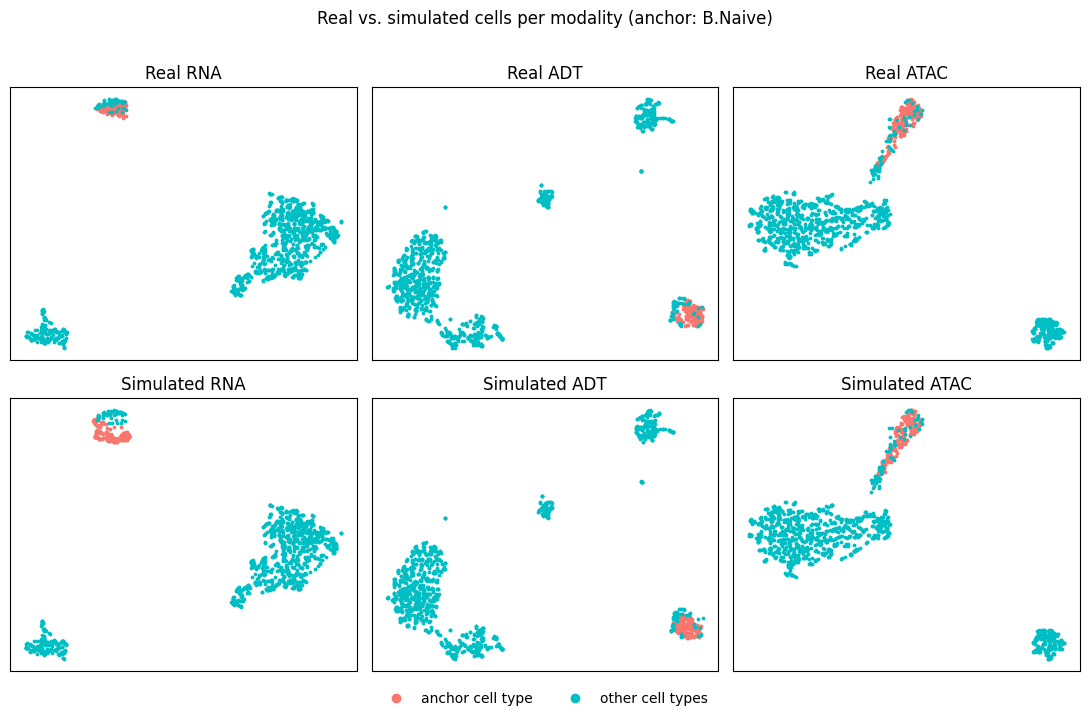

In [11]:
from sklearn.decomposition import PCA

real_labels = sim['real_label'].iloc[:, 0].values
sim_labels  = sim['label'].iloc[:, 0].values
GROUP_COLOR = {'anchor cell type': '#F8766D', 'other cell types': '#00BFC4'}   # two fixed groups, not cell types

def group_of(labels):                               # tag each cell: the anchor type vs everything else
    return np.where(labels == ANCHOR, 'anchor cell type', 'other cell types')

fig, axes = plt.subplots(2, 3, figsize=(11, 7.2))
for col, mod in enumerate(['rna', 'adt', 'atac']):
    real_mat = sim[f'real_{mod}'].values            # cells x features (real reference)
    aug_mat  = sim[mod].values                      # cells x features (augmented set)

    stacked = np.vstack([real_mat, aug_mat])
    top_var = np.argsort(stacked.var(0))[::-1][:1000]           # top-1000 most variable features
    z = stacked[:, top_var]
    z = (z - z.mean(0)) / (z.std(0) + 1e-8)                     # z-score
    n_comp = min(50, z.shape[1] - 1, z.shape[0] - 1)
    pcs = PCA(n_components=n_comp, random_state=42).fit_transform(z)   # denoise before UMAP
    xy = umap.UMAP(n_neighbors=20, min_dist=0.1, init='pca', random_state=42).fit_transform(pcs)

    n_real = real_mat.shape[0]
    real_xy, aug_xy = xy[:n_real], xy[n_real:]                 # split back: real (top row) / augmented (bottom)

    panels = [(axes[0, col], real_xy, real_labels, f'Real {mod.upper()}'),
              (axes[1, col], aug_xy,  sim_labels,  f'Simulated {mod.upper()}')]
    for ax, points, labels, title in panels:
        group = group_of(labels)
        for grp in ['anchor cell type', 'other cell types']:
            in_group = group == grp
            ax.scatter(points[in_group, 0], points[in_group, 1], s=3, color=GROUP_COLOR[grp], label=grp)
        ax.set_title(title)
        ax.set_xticks([])
        ax.set_yticks([])

handles = [plt.Line2D([0], [0], marker='o', ls='', color=GROUP_COLOR[g], label=g) for g in GROUP_COLOR]
fig.legend(handles=handles, loc='lower center', ncol=2, frameon=False)
fig.suptitle(f'Real vs. simulated cells per modality (anchor: {ANCHOR})')
plt.tight_layout(rect=[0, 0.04, 1, 0.97])
plt.show()

## 7. Modality combinations Matilda supports

Matilda works with **any combination of the three modalities** (RNA only, RNA + ADT, RNA + ATAC,
or RNA + ADT + ATAC) and picks the matching model automatically from what you pass. (Internally
Matilda labels these `rna_only` / `CITEseq` / `SHAREseq` / `TEAseq`, after the assays they typically
come from, but your data needn't be those specific protocols: only the modalities present matter.)
Just leave a modality out of the call to drop it.

The dataset is rna_only


  0%|          | 0/30 [00:00<?, ?it/s]

  7%|▋         | 2/30 [00:00<00:01, 15.97it/s]

 13%|█▎        | 4/30 [00:00<00:01, 17.55it/s]

 20%|██        | 6/30 [00:00<00:01, 18.18it/s]

...

 53%|█████▎    | 8/15 [00:00<00:00, 21.41it/s]

 73%|███████▎  | 11/15 [00:00<00:00, 21.59it/s]

 93%|█████████▎| 14/15 [00:00<00:00, 21.72it/s]

100%|██████████| 15/15 [00:00<00:00, 18.21it/s]

The dataset is CITEseq


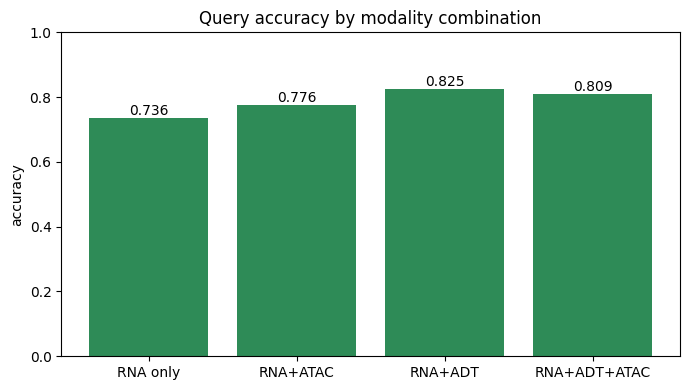

In [12]:
def query_acc(adt_tr=None, atac_tr=None, adt_te=None, atac_te=None):
    f = matilda.train(rna, adt=adt_tr, atac=atac_tr, labels=labels, seed=1)
    q = {'rna': te_rna}
    if adt_te  is not None: q['adt']  = adt_te
    if atac_te is not None: q['atac'] = atac_te
    r = matilda.classify(q, model=f, query_labels=te_lab).predictions
    return (r.predicted == r.real).mean()

vals = {
    'RNA only':     query_acc(),
    'RNA+ATAC':     query_acc(atac_tr=atac, atac_te=te_atac),
    'RNA+ADT':      query_acc(adt_tr=adt,  adt_te=te_adt),
    # RNA+ADT+ATAC reuses the already-trained TEA-seq model from section 2 (its result is
    # `pred`, computed in section 3); the other three bars each train a fresh model for their
    # own modality set inside query_acc(), so nothing is trained twice.
    'RNA+ADT+ATAC': (pred.predicted == pred.real).mean(),
}
plt.figure(figsize=(7, 4))
plt.bar(list(vals), list(vals.values()), color='seagreen')
plt.ylim(0, 1)
for i, value in enumerate(vals.values()):
    plt.text(i, value + 0.01, f'{value:.3f}', ha='center')
plt.title('Query accuracy by modality combination')
plt.ylabel('accuracy')
plt.tight_layout()
plt.show()


## 8. Session info


In [13]:
import sys, numpy, pandas, torch, anndata, umap
for m in (numpy, pandas, torch, anndata, umap, matilda):
    print(f'{m.__name__:10s} {m.__version__}')
print(f'{"python":10s} {sys.version.split()[0]}')


numpy      1.23.5
pandas     1.5.3
torch      2.1.2+cu121
anndata    0.10.9
umap       0.5.12
matilda    0.2.0
python     3.9.25
